In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

lineups = pd.read_parquet("../data/raw/lineups.parquet")
events = pd.read_parquet("../data/raw/events.parquet")

FULLBACK_LABELS = [
    "Left Back",
    "Right Back",
    "Left Wing Back",
    "Right Wing Back"
]

DEFENSIVE_MIDFIELD_LABELS = [
    "Center Defensive Midfield",
    "Left Defensive Midfield",
    "Right Defensive Midfield"
]

CREATIVE_MIDFIELD_LABELS = [
    "Center Midfield",
    "Left Midfield",
    "Right Midfield",
    "Left Center Midfield",
    "Right Center Midfield",
    "Center Attacking Midfield",
    "Left Attacking Midfield",
    "Right Attacking Midfield"
]

def extract_positions(position_history):
    if not isinstance(position_history, (list, tuple, np.ndarray)):
        return []
    
    return [
        stint["position"]
        for stint in position_history
        if isinstance(stint, dict) and "position" in stint
    ]

lineups["position_list"] = (
    lineups["positions"].apply(extract_positions)
)

positions_long = (
    lineups[
        [
            "player_id",
            "player_name",
            "position_list"
        ]
    ]
    .explode("position_list")
    .rename(columns={"position_list": "position"})
    .dropna(subset=["position"])
)

print(positions_long.shape)

print(
    sorted(
        positions_long["position"].unique()
    )
)

(13609, 3)
['Center Attacking Midfield', 'Center Back', 'Center Defensive Midfield', 'Center Forward', 'Center Midfield', 'Goalkeeper', 'Left Attacking Midfield', 'Left Back', 'Left Center Back', 'Left Center Forward', 'Left Center Midfield', 'Left Defensive Midfield', 'Left Midfield', 'Left Wing', 'Left Wing Back', 'Right Attacking Midfield', 'Right Back', 'Right Center Back', 'Right Center Forward', 'Right Center Midfield', 'Right Defensive Midfield', 'Right Midfield', 'Right Wing', 'Right Wing Back']


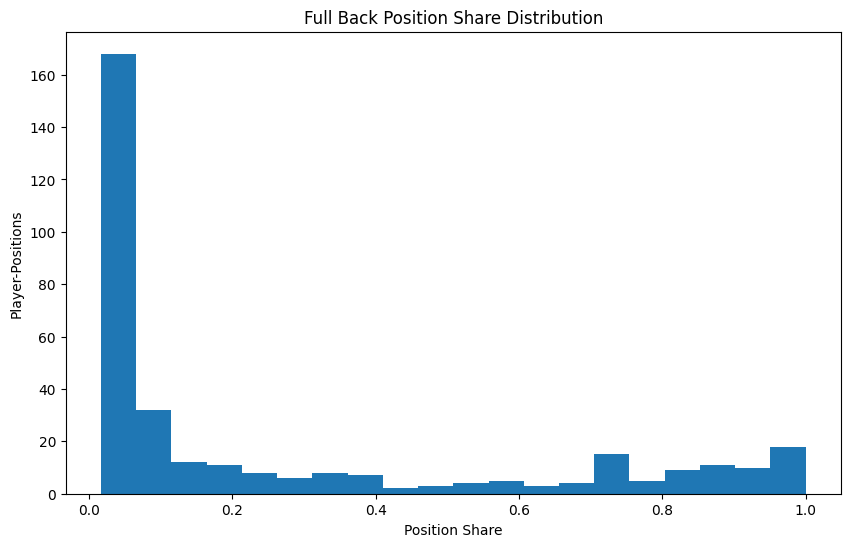

,player_id,player_name,position,appearances,total_appearances,position_share
0,3023,Yuri Berchiche Izeta,Left Back,22,22,1.000000
2514,27054,Roberto Lago Soto,Left Back,21,21,1.000000
1313,6844,Federico Ricca Rostagnol,Left Back,8,8,1.000000
1669,10727,Răzvan Dincă Raț,Left Back,10,10,1.000000
556,6400,Aleix Vidal Parreu,Right Back,9,9,1.000000
2123,23972,José Joaquín Matos García,Left Back,1,1,1.000000
127,4741,Juan Rafael Fuentes Hernández,Left Back,11,11,1.000000
2239,24577,Salvador Ruiz Rodríguez,Left Back,2,2,1.000000
2250,24711,David Carmona Sierra,Right Back,1,1,1.000000
2512,26941,Francisco Javier García Noblejas Hernanz,Left Back,1,1,1.000000


In [36]:
position_counts = (
    positions_long
    .groupby(
        [
            "player_id",
            "player_name",
            "position"
        ]
    )
    .size()
    .reset_index(name="appearances")
)


player_totals = (
    position_counts
    .groupby(
        [
            "player_id",
            "player_name"
        ]
    )["appearances"]
    .sum()
    .reset_index(name="total_appearances")
)


lineup_position_shares = (
    position_counts
    .merge(
        player_totals,
        on=["player_id", "player_name"]
    )
)

lineup_position_shares["position_share"] = (
    lineup_position_shares["appearances"]
    / lineup_position_shares["total_appearances"]
)


lineup_fullback_shares = (
    lineup_position_shares[
        lineup_position_shares["position"]
        .isin(FULLBACK_LABELS)
    ]
    .copy()
)


plt.figure(figsize=(10, 6))

plt.hist(
    lineup_fullback_shares["position_share"],
    bins=20
)

plt.xlabel("Position Share")
plt.ylabel("Player-Positions")
plt.title("Full Back Position Share Distribution")

plt.show()


lineup_fullback_shares.sort_values(
    "position_share",
    ascending=False
).head(20)

In [37]:
lineup_candidates = lineup_fullback_shares[
    lineup_fullback_shares["position_share"].between(
        0.60,
        0.80
    )
]

lineup_candidates[
    ["player_name", "position", "position_share"]
].sort_values(
    "position_share"
)

,player_name,position,position_share
2466,Borja Ekiza Imaz,Right Back,0.600000
1709,Diogo José Rosário Gomes Figueiras,Right Back,0.600000
1202,Javier López Rodríguez,Right Back,0.641026
1186,Antonio García Aranda,Left Back,0.645161
769,Óscar de Marcos Arana,Right Back,0.652174
2567,Bojan Jokić,Left Back,0.666667
2168,Joaquín José Marín Ruiz,Right Back,0.676471
1426,David García Santana,Right Back,0.695652
2,Danilo Luiz da Silva,Right Back,0.700000
1721,José Ignacio Martínez García,Left Back,0.708333


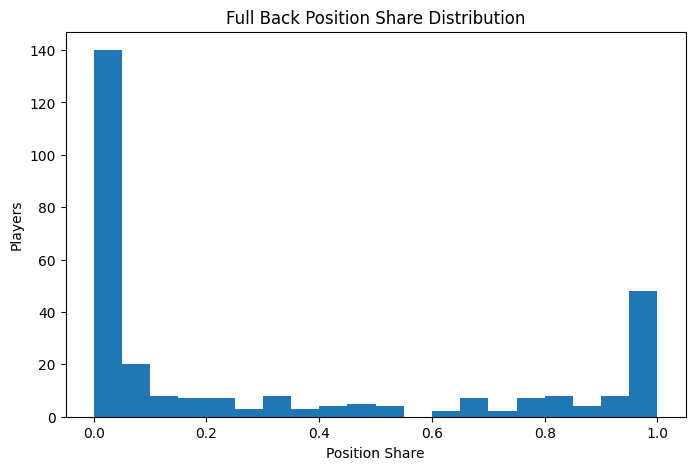

,player_id,player,position,events,total_events,position_share
0,3023.0,Yuri Berchiche Izeta,Left Back,3587,3587,1.0
158,5211.0,Jordi Alba Ramos,Left Back,6718,6718,1.0
541,6569.0,Roberto José Rosales Altuve,Right Back,5283,5283,1.0
1071,6787.0,Pedro López Muñoz,Right Back,2214,2214,1.0
1178,6844.0,Federico Ricca Rostagnol,Left Back,1005,1005,1.0
1503,10727.0,Răzvan Dincă Raț,Left Back,1509,1509,1.0
1907,23972.0,José Joaquín Matos García,Left Back,171,171,1.0
2007,24577.0,Salvador Ruiz Rodríguez,Left Back,126,126,1.0
2015,24686.0,Roberto Canella Suárez,Left Back,1009,1009,1.0
2016,24711.0,David Carmona Sierra,Right Back,152,152,1.0


In [38]:
sorted(events["position"].dropna().unique())

position_counts = (
    events
    .dropna(subset=["player_id", "position"])
    .groupby(
        ["player_id", "player", "position"]
    )
    .size()
    .reset_index(name="events")
)

player_totals = (
    position_counts
    .groupby(["player_id", "player"])["events"]
    .sum()
    .reset_index(name="total_events")
)

event_position_shares = position_counts.merge(
    player_totals,
    on=["player_id", "player"]
)

event_position_shares["position_share"] = (
    event_position_shares["events"]
    / event_position_shares["total_events"]
)

event_fullback_shares = event_position_shares[
    event_position_shares["position"].isin(FULLBACK_LABELS)
].copy()

plt.figure(figsize=(8, 5))

plt.hist(
    event_fullback_shares["position_share"],
    bins=20
)

plt.xlabel("Position Share")
plt.ylabel("Players")
plt.title("Full Back Position Share Distribution")

plt.show()

event_fullback_shares.sort_values(
    "position_share",
    ascending=False
).head(20)


In [39]:
event_candidates = event_fullback_shares[
    event_fullback_shares["position_share"].between(
        0.60,
        0.80
    )
]

event_candidates[
    ["player", "position", "position_share"]
].sort_values(
    "position_share"
)

,player,position,position_share
115,Jesús Gámez Duarte,Right Back,0.638770
1115,Jonathan Castro Otto,Left Back,0.638927
1773,Álvaro Arbeloa Coca,Left Back,0.662675
2154,Javier Garrido Behovide,Left Back,0.672488
943,Juan Francisco Moreno Fuertes,Right Back,0.674580
1282,David García Santana,Right Back,0.675400
1067,Antonio García Aranda,Left Back,0.675553
1321,João Pedro Cavaco Cancelo,Right Back,0.680846
1466,Iván López Mendoza,Right Back,0.680942
1542,Diogo José Rosário Gomes Figueiras,Right Back,0.724346


In [41]:
def find_player(name):
    print("LINEUPS")
    display(
        lineup_position_shares[
            lineup_position_shares["player_name"]
            .str.contains(
                name,
                case=False,
                na=False
            )
        ]
        .sort_values(
            "position_share",
            ascending=False
        )
    )

    print("EVENTS")
    display(
        event_position_shares[
            event_position_shares["player"]
            .str.contains(
                name,
                case=False,
                na=False
            )
        ]
        .sort_values(
            "position_share",
            ascending=False
        )
    )

In [44]:
find_player("Pedro López Muñoz")

LINEUPS


,player_id,player_name,position,appearances,total_appearances,position_share
1190,6787,Pedro López Muñoz,Right Back,21,22,0.954545
1191,6787,Pedro López Muñoz,Right Defensive Midfield,1,22,0.045455


EVENTS


,player_id,player,position,events,total_events,position_share
1071,6787.0,Pedro López Muñoz,Right Back,2214,2214,1.0


In [ ]:
lineup_population = set(
    lineup_fullback_shares[
        lineup_fullback_shares["position_share"] >= 0.70
    ]["player_id"]
)

event_population = set(
    event_fullback_shares[
        event_fullback_shares["position_share"] >= 0.70
    ]["player_id"]
)

lineup_only = lineup_population - event_population

event_only = event_population - lineup_population

print(f"Lineup Only: {len(lineup_only)}")
print(f"Event Only: {len(event_only)}")